In [1]:
# Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

import matplotlib as mpl
import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

In [2]:
# Define Model

def bb(f, T):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    return (2 * h  * f**3.0 / c**2.0) / (np.exp(h * f / (k * T)) - 1.0)

def bbGrad(f, T):
    c = 2.99792458e10    # units: cm / s
    h = 6.62607015e-27   # units: erg * s
    k = 1.380649e-16     # units: erg / K
    return (2 * h  * f**3.0 / c**2.0) * (h * f / (k * T**2.0)) * np.exp(h * f / (k * T)) / (np.exp(h * f / (k * T)) - 1.0)**2.0

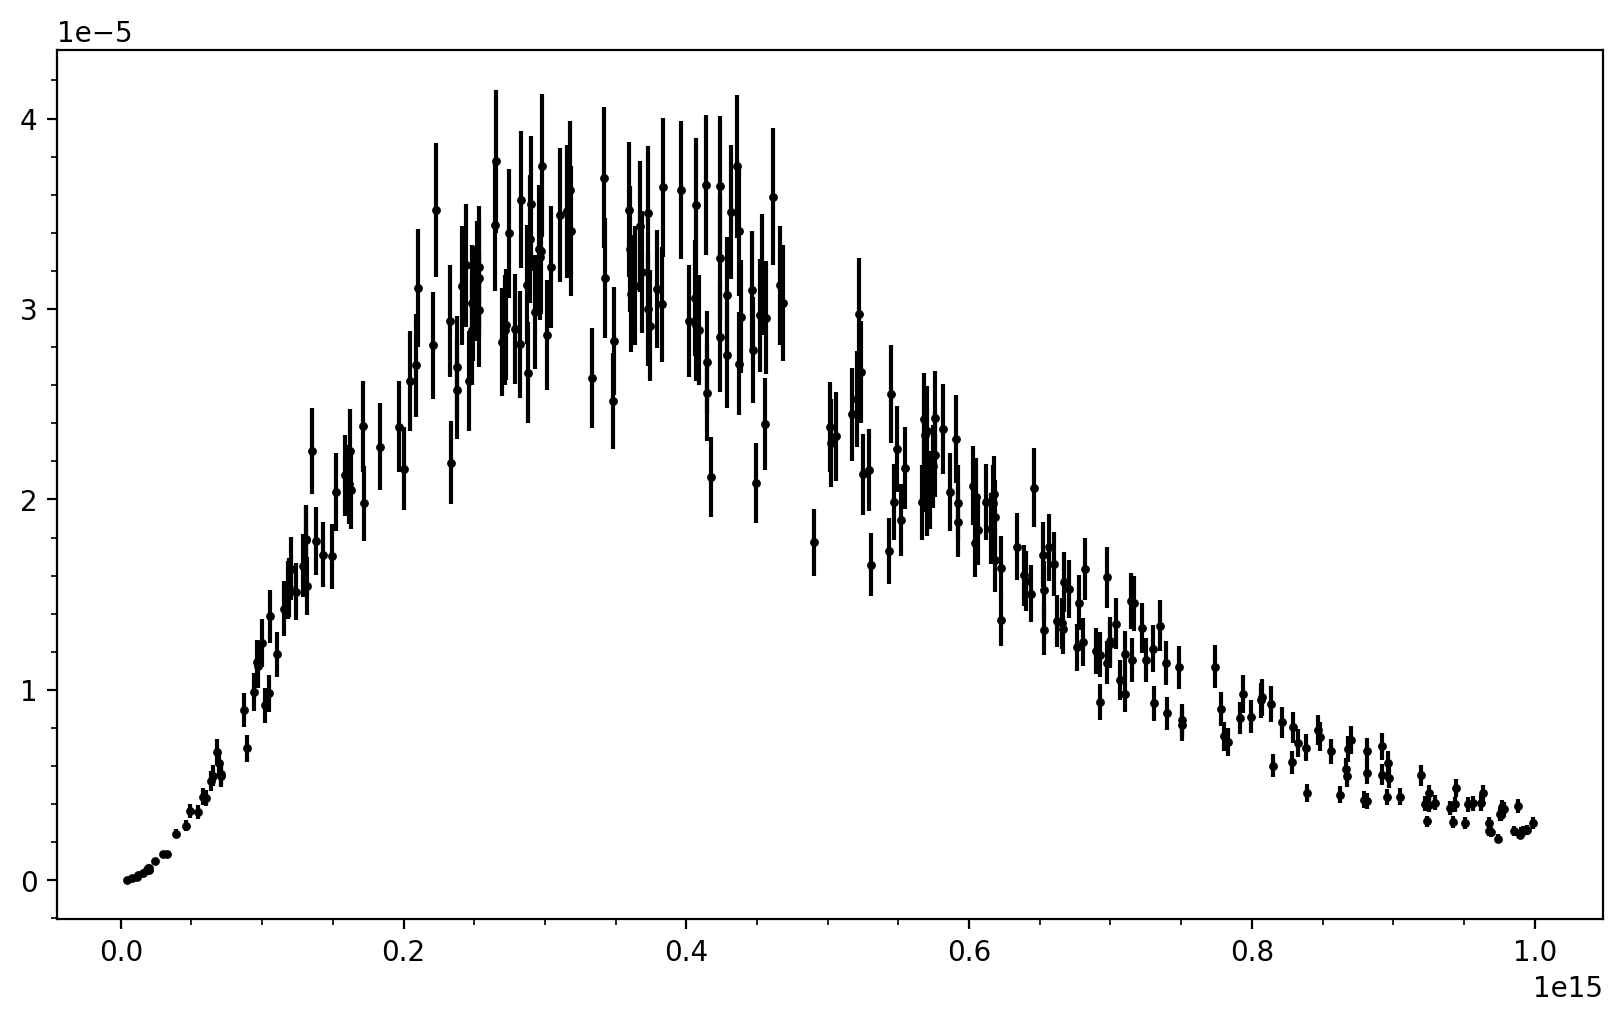

In [3]:
# Generate Data

np.random.seed(0)

TT1 = 5.7e3
TT2 = 5.5e3

N1 = 175
N2 = 125

u = 0.1

ff1 = np.random.uniform(0.0, 1e15, N1)

II1 = bb(ff1, TT1)
II1 += np.random.normal(0, u * II1)

ff2 = np.random.uniform(0.0, 1e15, N2)

II2 = bb(ff2, TT2)
II2 += np.random.normal(0, u * II2)

ff = np.concatenate((ff1, ff2))

II = np.concatenate((II1, II2))

uII = u * II

plt.errorbar(ff, II, yerr=uII, fmt='k.', ms=4.32)
plt.show()

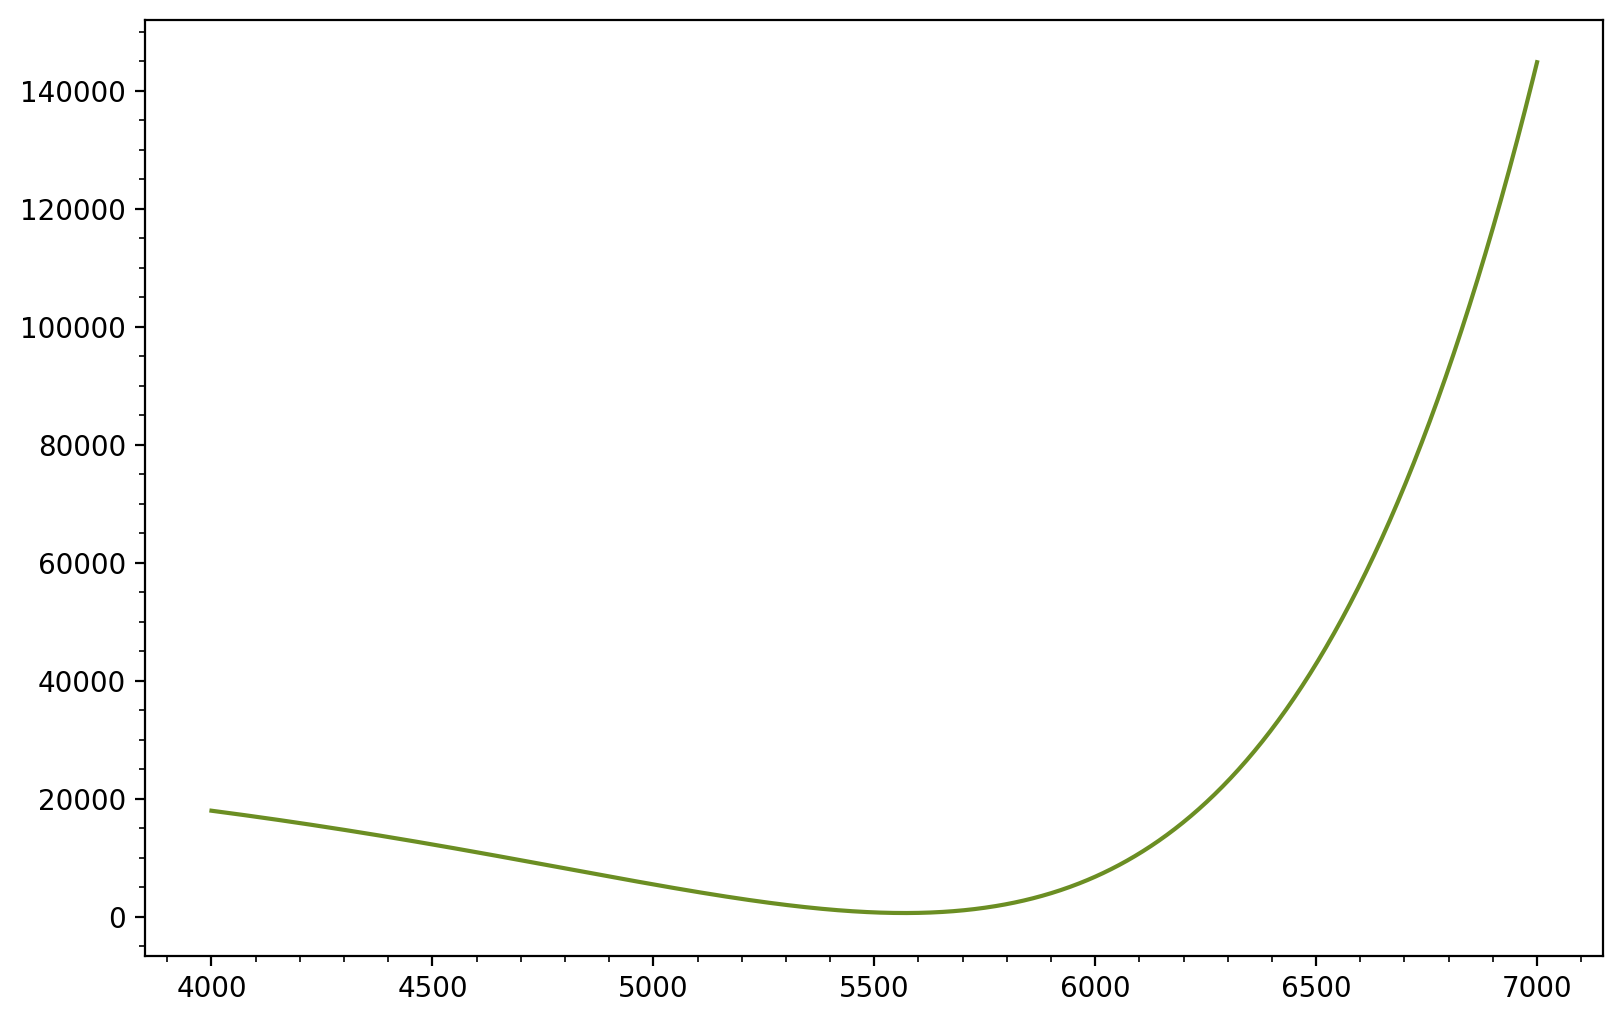

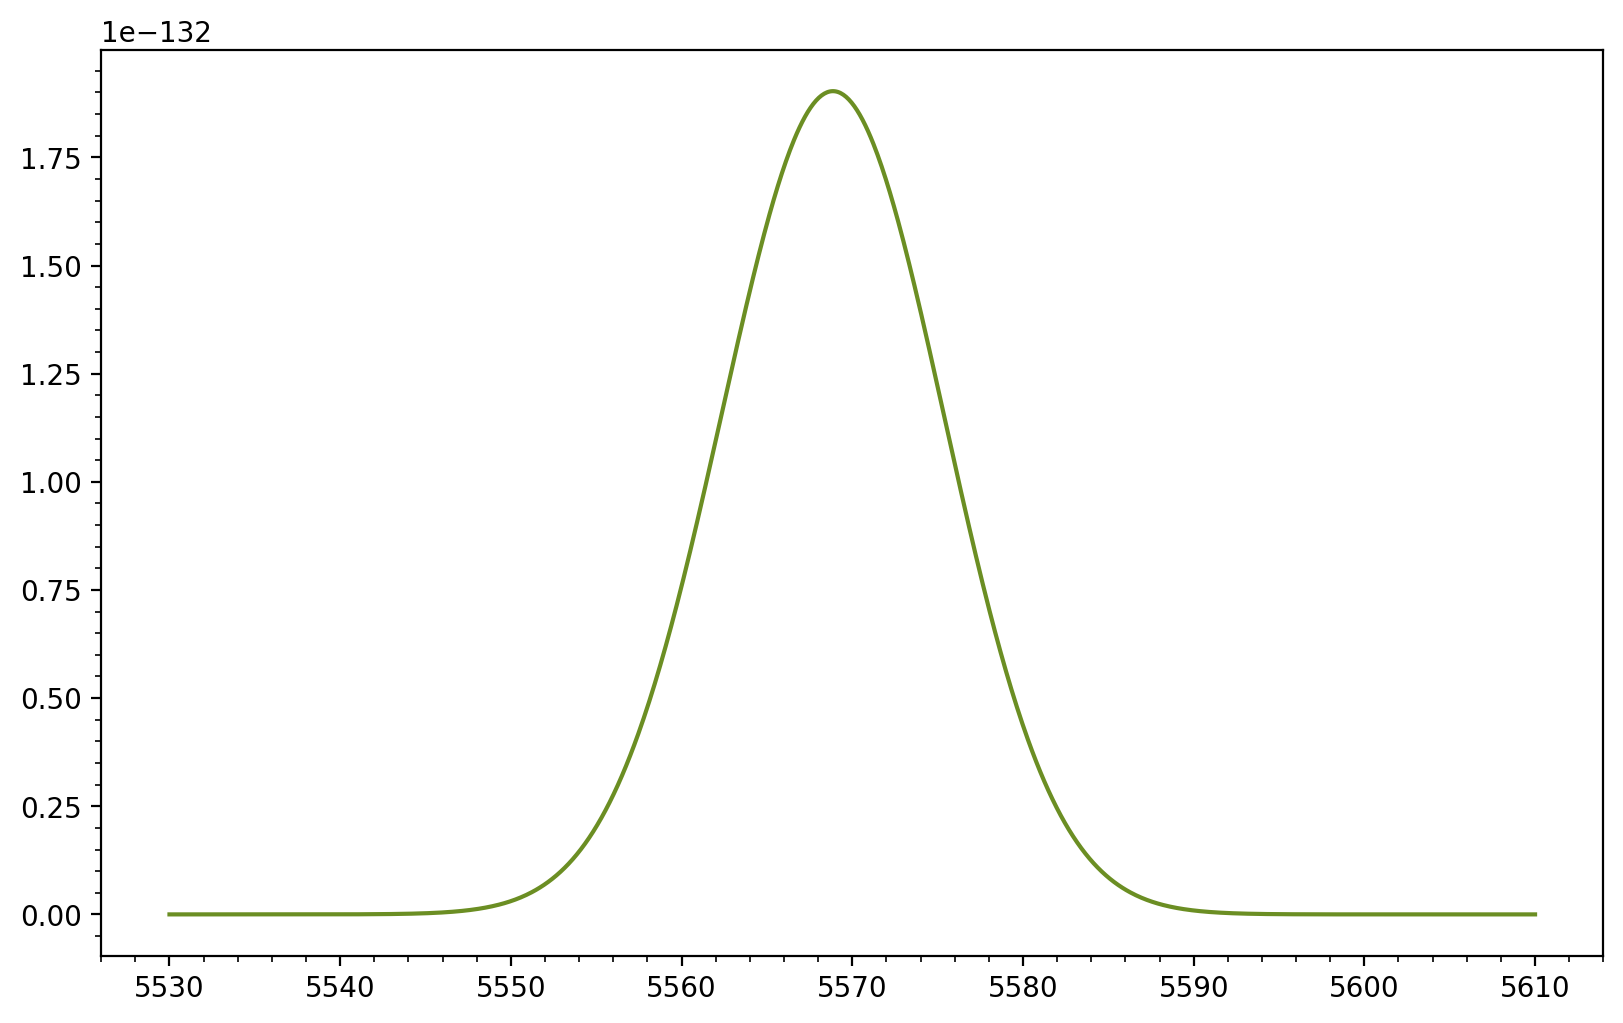

In [4]:
# Calculate Chi Squared

def chiSq(I, f, s, T):
    return np.sum((I - bb(f, T))**2.0 / s**2.0)

def chiSqGrad(I, f, s, T):
    return np.sum(-2.0 * (I - bb(f, T)) * bbGrad(f, T) / s**2.0)

ttLog = np.linspace(4e3, 7e3, 1000)

loglike = np.zeros(len(ttLog))
for i in range(len(ttLog)):
    loglike[i] = chiSq(II, ff, uII, ttLog[i])

plt.plot(ttLog, loglike)

plt.show()
plt.close()

ttLin = np.linspace(5.530e3, 5.610e3, 1000)

linlike = np.zeros(len(ttLin))
for i in range(len(ttLin)):
    linlike[i] = chiSq(II, ff, uII, ttLin[i])

plt.plot(ttLin, np.exp(-linlike / 2))

plt.show()
plt.close()



initialization:   T = 6900 K
  optimization:   T = 5569 K
    iterations:   k = 64


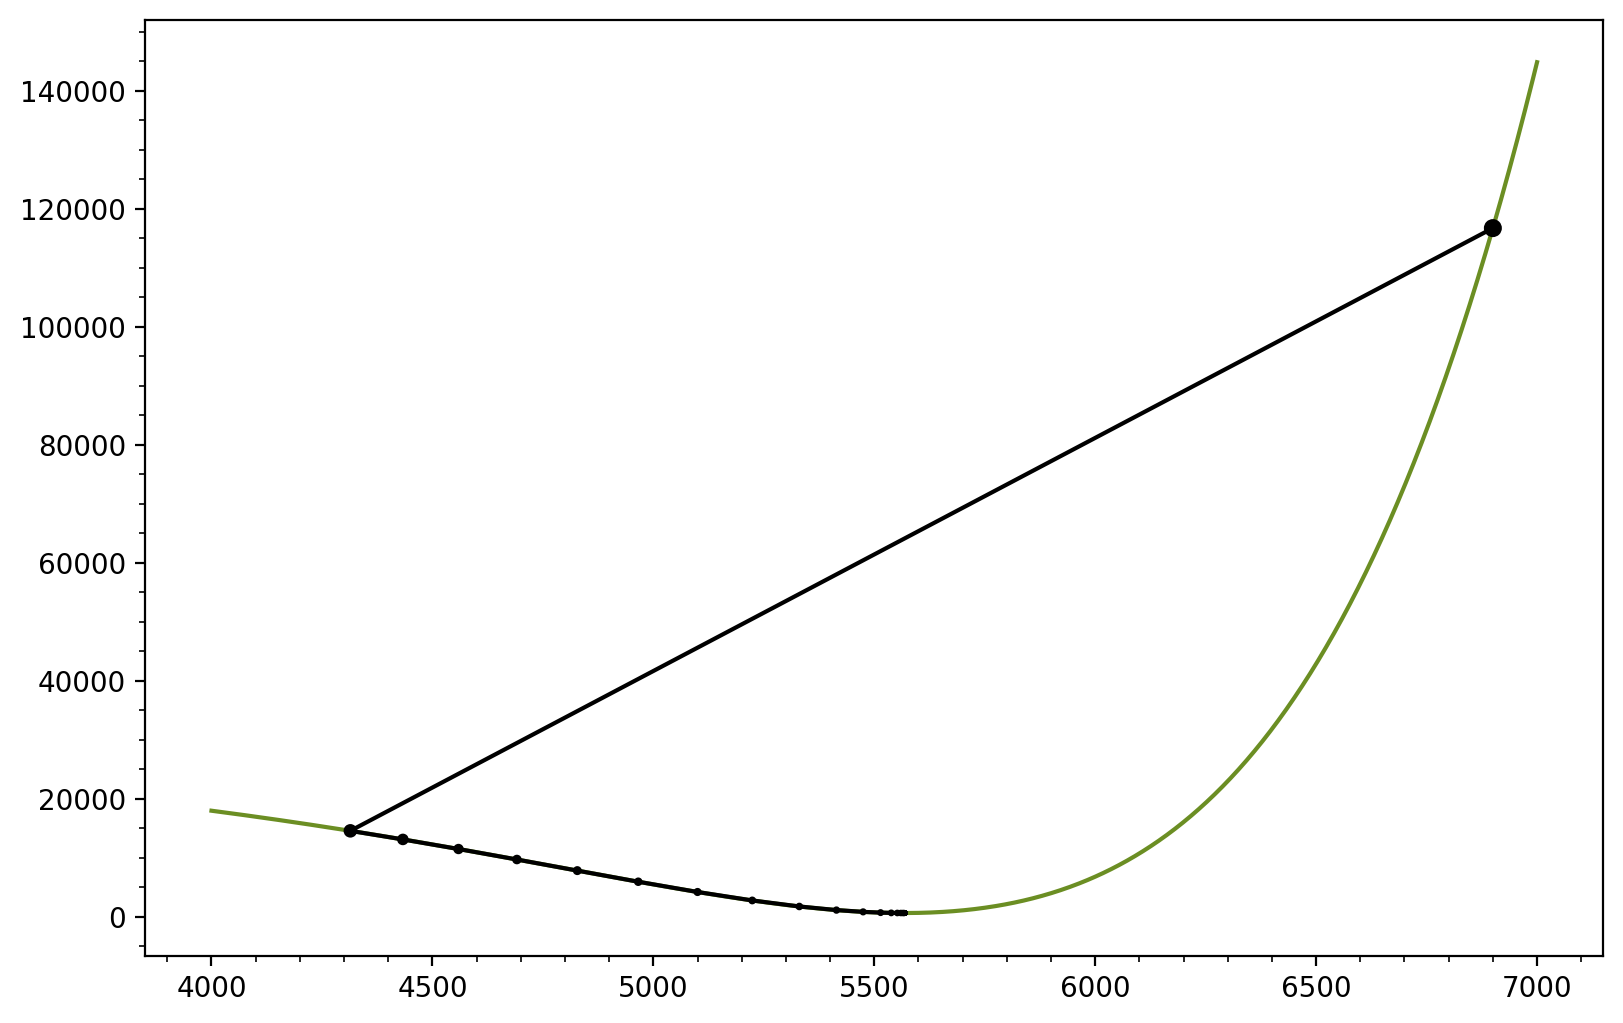

In [5]:
# Implement Gradient Descent

def gradDesc(I, f, s, T, alpha = 1e1, epsilon = 1e-16):
    theta = np.array([T])
    k = 0
    while True:
        grad = chiSqGrad(I, f, s,theta[k])
        theta = np.append(theta, theta[k] - alpha * grad)
        k += 1
        if np.abs(theta[k] - theta[k - 1]) / theta[k - 1] < epsilon:
            break
        if k >= 100000:
            break
    print('\n')
    print(f'initialization:   T = {T:.0f} K')
    print(f'  optimization:   T = {theta[-1]:.0f} K')
    print(f'    iterations:   k = {k}')
    return [theta, k]

test, k = gradDesc(II, ff, uII, 6.9e3)

step = np.zeros(len(test))
for i in range(len(test)):
    step[i] = chiSq(II, ff, uII, test[i])

plt.plot(ttLog, loglike)

plt.scatter(test, step, s=(30 / (np.arange(k + 1) + 1)), c='k', zorder=10)
plt.plot(test, step, 'k')

plt.show()
plt.close()

opt = test[-1]



initialization:   T = 6900 K
  optimization:   T = 5569 K
    iterations:   k = 145


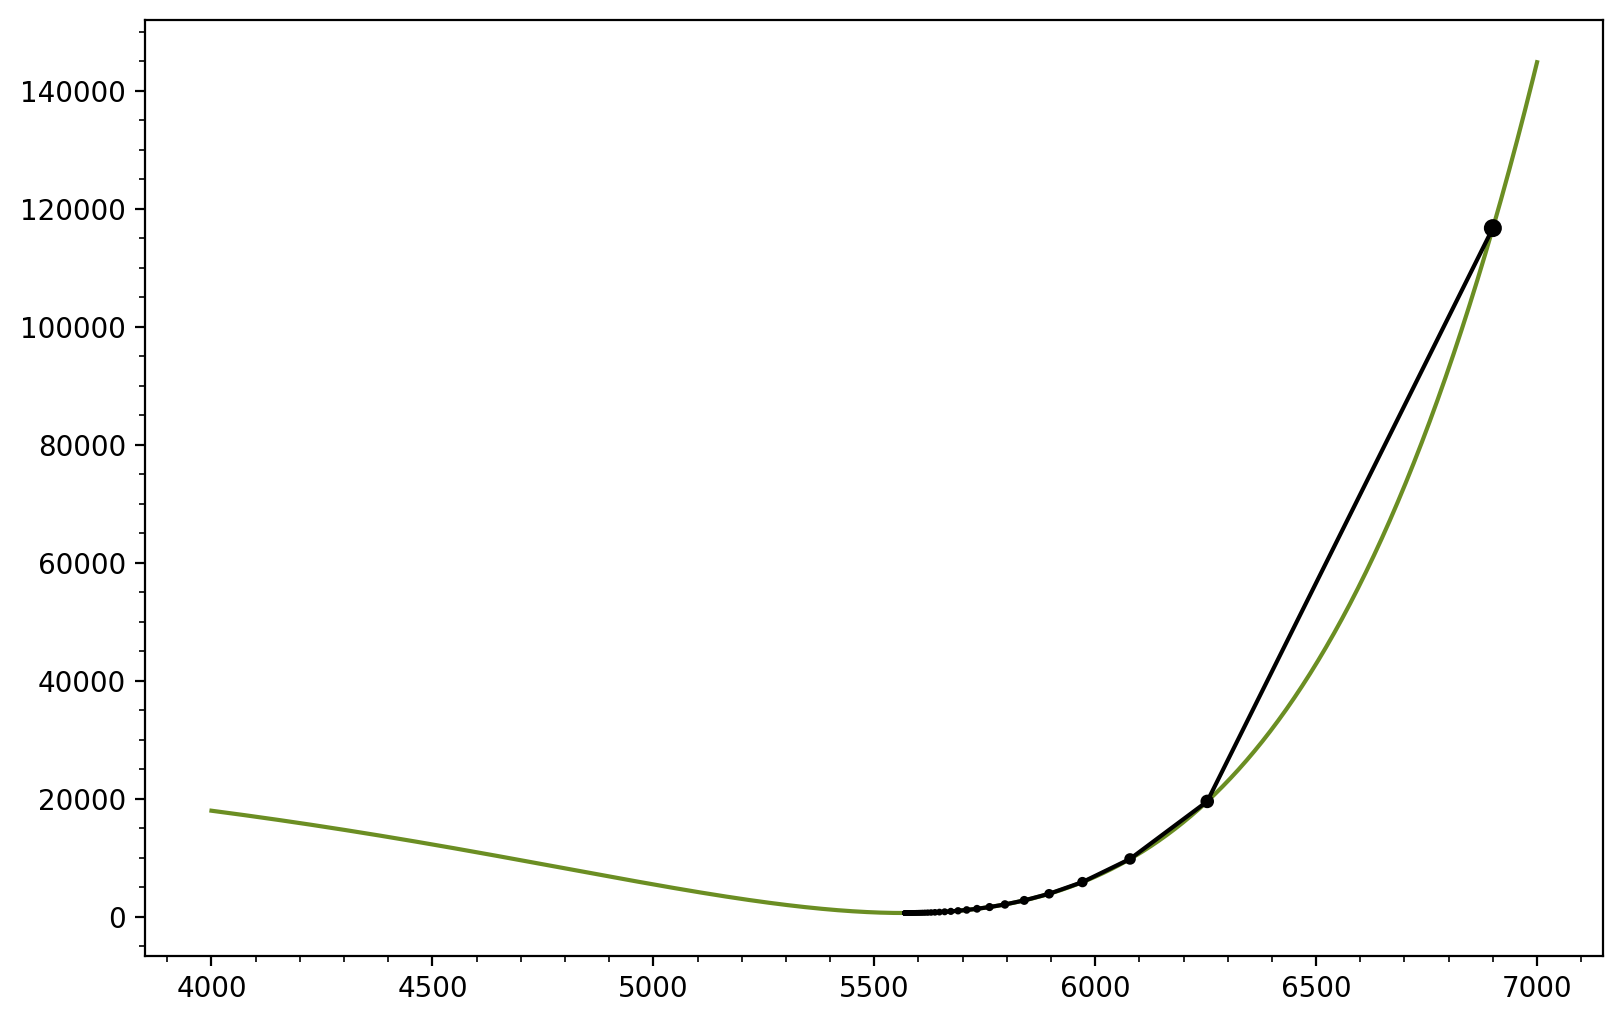

In [6]:
# Implement Line Search

def lineSearch(I, f, s, T, k, grad, alpha, kappa, tau):
    while chiSq(I, f, s, T) - chiSq(I, f, s, T - alpha * grad) < kappa * alpha * grad**2.0:
        alpha *= tau
    return alpha

def gradDescLineSearch(I, f, s, T, init = 1e1, epsilon = 1e-16, kappa = 0.5, tau = 0.5):
    theta = np.array([T])
    alpha = np.array([init])
    k = 0
    while True:
        grad = chiSqGrad(I, f, s,theta[k])
        alpha[-1] = lineSearch(I, f, s, theta[k], k, grad, alpha[-1], kappa, tau)
        theta = np.append(theta, theta[k] - alpha * grad)
        k += 1
        if np.abs(theta[k] - theta[k - 1]) / theta[k - 1] < epsilon:
            break
        if k >= 100000:
            break
    print('\n')
    print(f'initialization:   T = {T:.0f} K')
    print(f'  optimization:   T = {theta[-1]:.0f} K')
    print(f'    iterations:   k = {k}')
    return [theta, k]

test, k = gradDescLineSearch(II, ff, uII, 6.9e3)

step = np.zeros(len(test))
for i in range(len(test)):
    step[i] = chiSq(II, ff, uII, test[i])

plt.plot(ttLog, loglike)

plt.scatter(test, step, s=(30 / (np.arange(k + 1) + 1)), c='k', zorder=10)
plt.plot(test, step, 'k')

plt.show()
plt.close()

opt = test[-1]

done:   generated 25000 samples after 68527 evaluations with acceptance ratio 36.48%


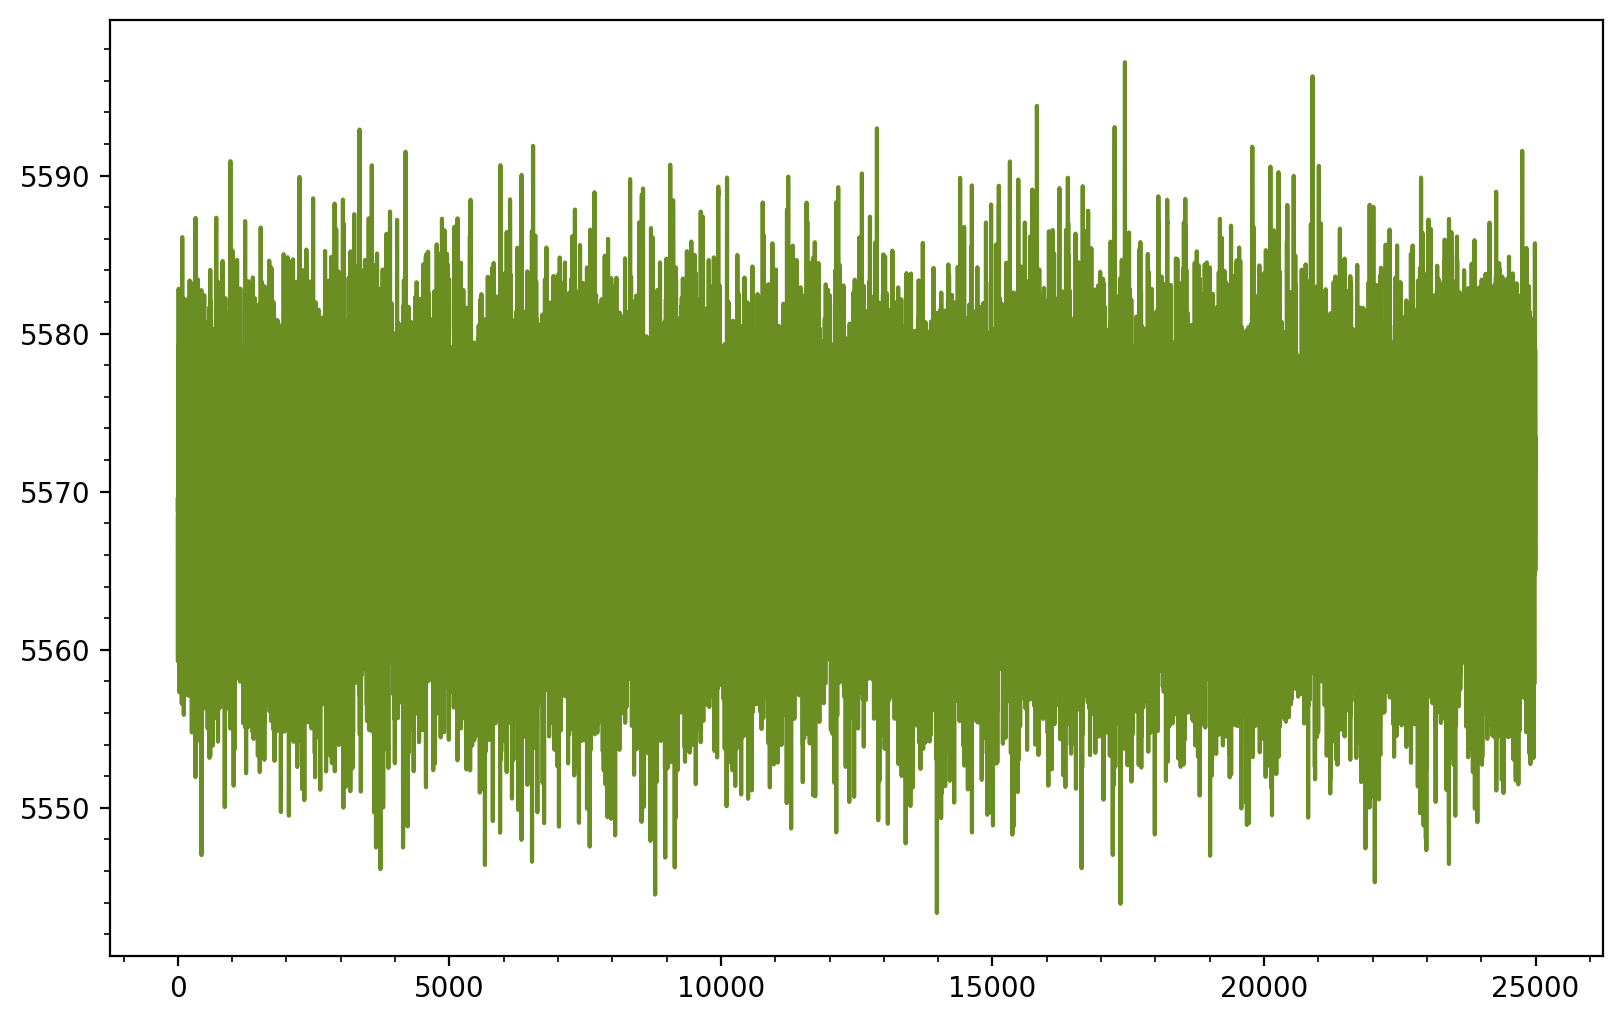

In [52]:
# Implement Metropolos MCMC

def metroMCMC(n, T, I, f, s, h = 2e1, m = 10**6):
    theta = np.array([T])
    k = 0
    l = 0
    while n > l + 1 and k < m:
        th = np.random.normal(theta[l], h)
        r = np.exp((chiSq(I, f, s, theta[l]) - chiSq(I, f, s, th)) / 2)
        if r >= 1.0:
            theta = np.append(theta, th)
            l += 1
        else:
            p = np.random.uniform(0.0, 1.0)
            if r >= p:
                theta = np.append(theta, th)
                l += 1
        k += 1
    ac = n / k
    print(f'done:   generated {n} samples after {k} evaluations with acceptance ratio {100 * ac:.2f}%')
    return [theta, ac]

chain, k = metroMCMC(25000, opt, II, ff, uII)

plt.plot(chain)

plt.show()
plt.close()

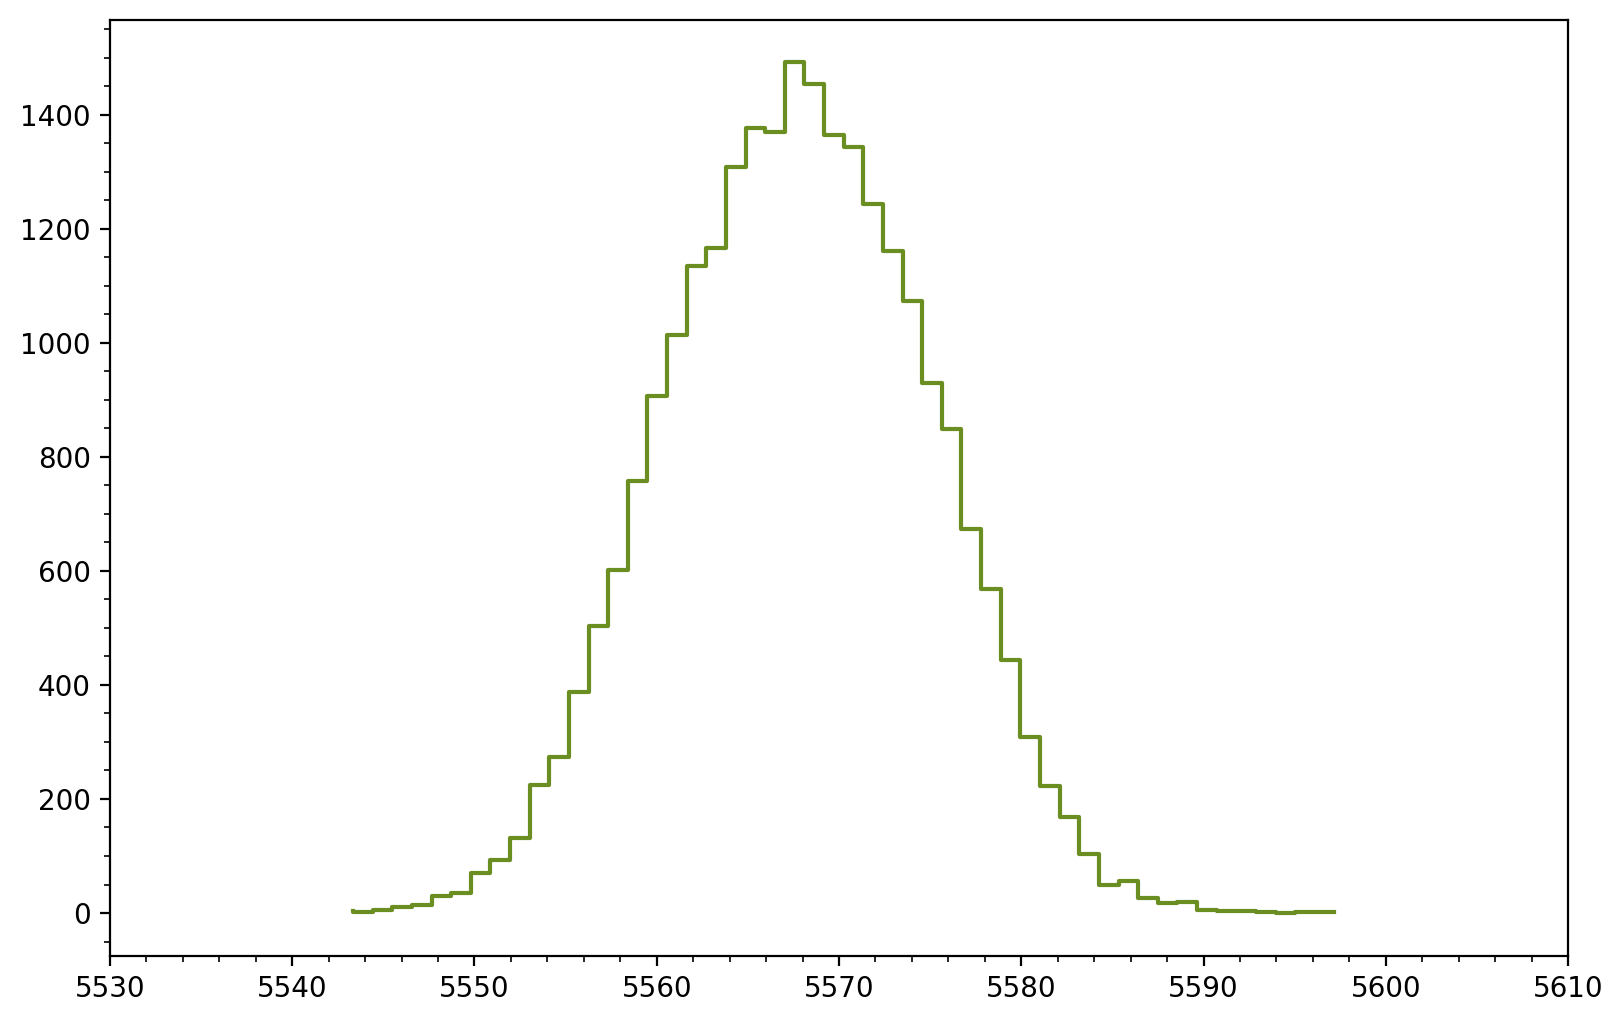

In [53]:
hist, edge = np.histogram(chain, bins=50)
hist = np.array([*hist, hist[-1]])

plt.step(edge, hist)

plt.xlim(5530, 5610)

plt.show()
plt.close()

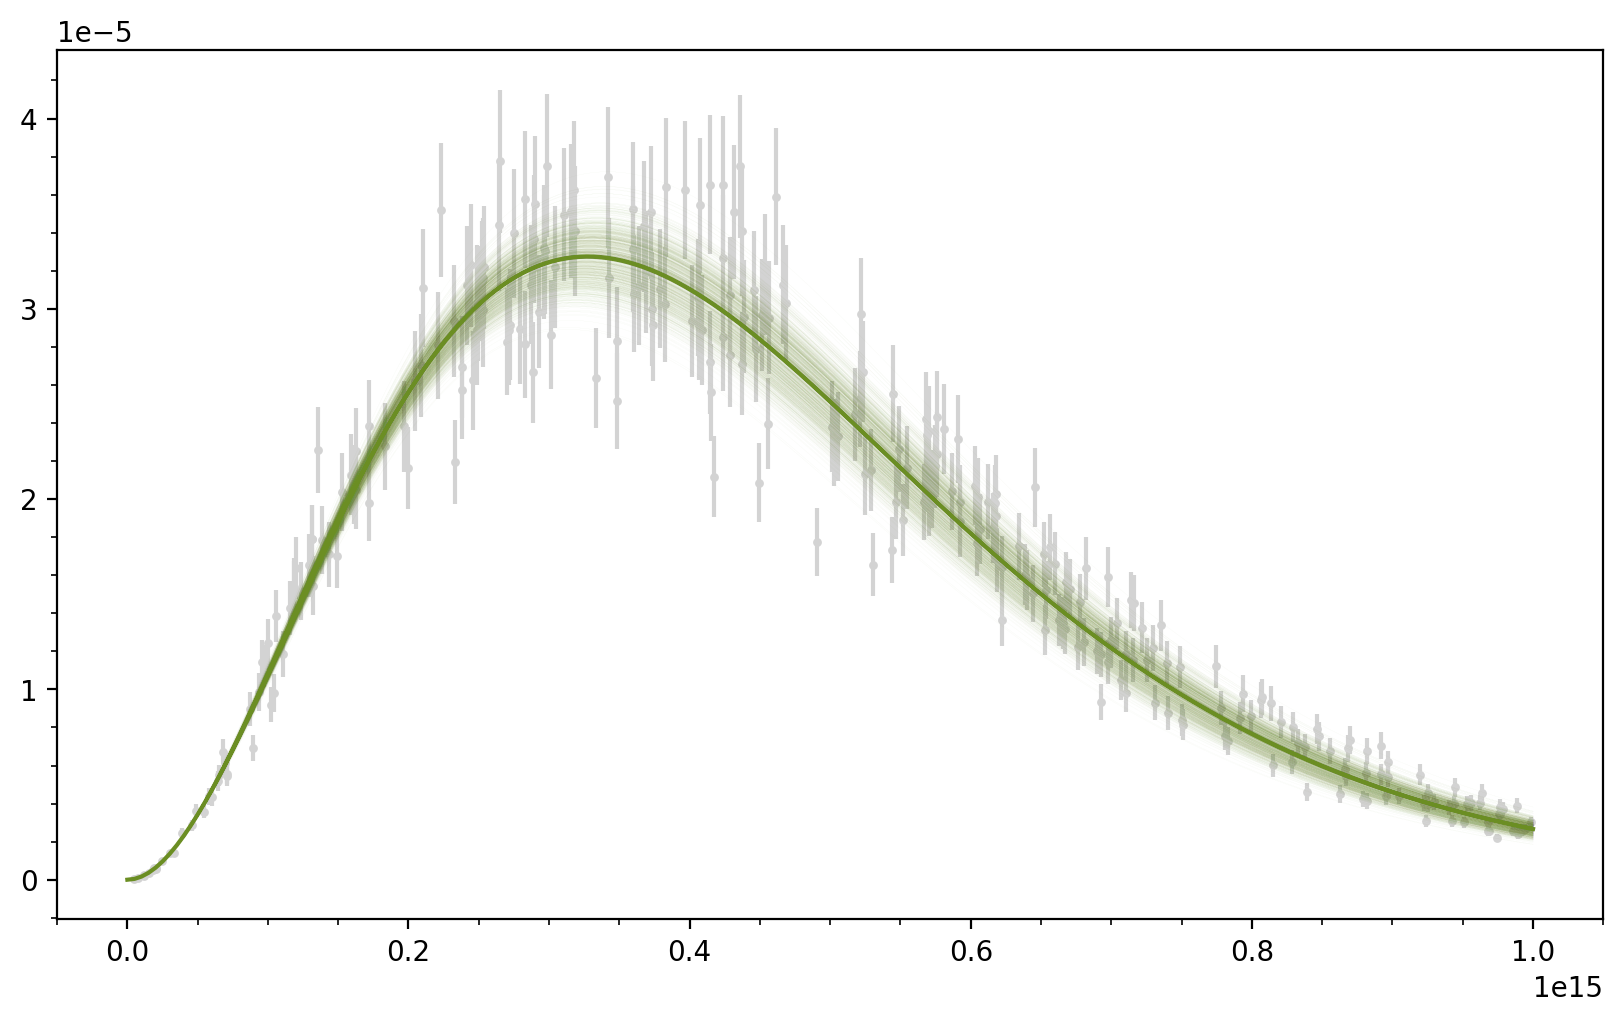

In [54]:
freq = np.linspace(1e-1, 1e15, 200)

rad = bb(freq, opt)

plt.errorbar(ff, II, yerr=uII, fmt='.', c='lightgrey', ms=4.32, zorder=-1)

plt.plot(freq, rad)

samp = chain[::25]

for el in samp:
    plt.plot(freq, bb(freq, opt - 1e1 * (opt - el)), c='olivedrab', lw=0.01, alpha=0.5, zorder=10000)

plt.show()
plt.close()

In [ ]:
# MCMC Uncertainty Propagation

